In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def inicializar_ambiente(linhas, colunas, densidade=0.1):
    """
    Cria a matriz do ambiente com itens (1) e espaços vazios (0).
    Distribuição: Aleatória uniforme (não paramétrica).
    """
    # Usando np.random.choice para garantir a distribuição uniforme baseada em probabilidade
    grid = np.random.choice(
        [0, 1], 
        size=(linhas, colunas), 
        p=[1 - densidade, densidade]
    )
    return grid

In [19]:
def visualizar_ambiente(grid, titulo):
    """
    Gera um gráfico do ambiente.
    Preto (1) representa os itens, Branco (0) representa o vazio.
    """
    plt.imshow(grid, cmap='binary', interpolation='nearest')
    plt.title(f"{titulo} (Densidade Real: {np.mean(grid)*100:.1f}%)")
    plt.xlabel("X (Células)")
    plt.ylabel("Y (Células)")
    plt.colorbar(label='0: Vazio | 1: Item')
    plt.savefig('ambiente_'+titulo+'.png')
    print("Gráfico gerado: ambiente_inicial.png")

In [7]:
# Configurações
LARGURA, ALTURA = 10, 10
DENSIDADE_ITENS = 0.1  # 10%

Gráfico gerado: ambiente_inicial.png


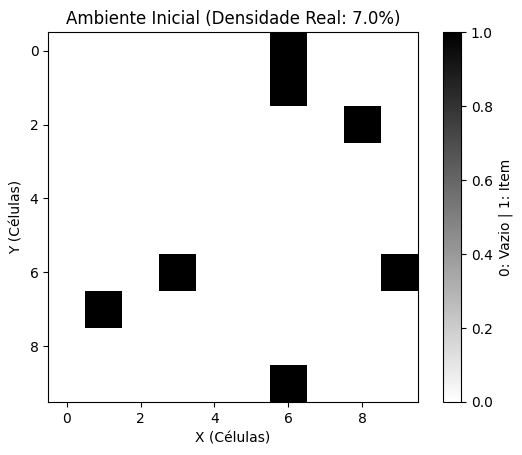

In [8]:
# Execução
ambiente = inicializar_ambiente(LARGURA, ALTURA, DENSIDADE_ITENS)
visualizar_ambiente(ambiente)

In [9]:
# Exportando para inspeção (conforme diretrizes)
pd.DataFrame(ambiente).to_csv('ambiente_inicial.csv', index=False)

In [ ]:
import random
import numpy as np

In [13]:
class Ant:
    def __init__(self, x, y, r=1):
        self.x = x
        self.y = y
        self.r = r
        self.carregando = False

    def move(self, max_x, max_y):
        """Movimento aleatório dentro dos limites da matriz."""
        direcoes = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        dx, dy = random.choice(direcoes)
        
        # Novas coordenadas com restrição de borda (Clamping)
        nova_x = max(0, min(max_x - 1, self.x + dx))
        nova_y = max(0, min(max_y - 1, self.y + dy))
        
        self.x, self.y = nova_x, nova_y

    def get_density(self, matrix):
        """Calcula f = n / área no raio r."""
        linhas, colunas = matrix.shape
        n = 0
        total_celulas = 0
        
        # Define os limites do quadrado (vizinhança de Moore)
        for i in range(self.x - self.r, self.x + self.r + 1):
            for j in range(self.y - self.r, self.y + self.r + 1):
                # Verifica se a célula vizinha está dentro da matriz
                if 0 <= i < linhas and 0 <= j < colunas:
                    n += matrix[i, j]
                    total_celulas += 1
        
        # Densidade f (entre 0 e 1)
        return n / total_celulas if total_celulas > 0 else 0

    def decidir_acao(self, matrix):
        f = self.get_density(matrix)
        item_na_celula = matrix[self.x, self.y]

        if not self.carregando:
            # Tentar PEGAR
            if item_na_celula == 1:
                p_pegar = 1 - f
                if random.random() < p_pegar:
                    matrix[self.x, self.y] = 0  # Remove da matriz
                    self.carregando = True
                    return "pegou"
        
        else:
            # Tentar LARGAR
            if item_na_celula == 0:
                p_largar = f
                if random.random() < p_largar:
                    matrix[self.x, self.y] = 1  # Devolve à matriz
                    self.carregando = False
                    return "largou"
        
        return "nada"

Iniciando simulação...
Gráfico gerado: ambiente_inicial.png
Simulação concluída!
Gráfico gerado: ambiente_inicial.png


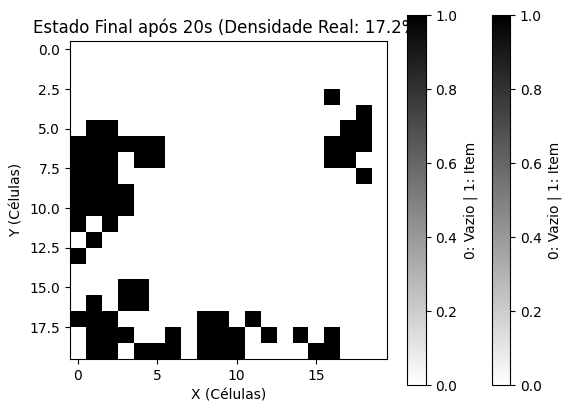

In [20]:
import time

# --- Configurações Finais ---
NUM_FORMIGAS = 15
DURACAO_SEGUNDOS = 20
LARGURA, ALTURA = 20, 20 # Aumentando um pouco para ver melhor o agrupamento
DENSIDADE_ITENS = 0.2

# 1. Inicializar Ambiente e Formigas
ambiente = inicializar_ambiente(LARGURA, ALTURA, DENSIDADE_ITENS)
formigas = [Ant(random.randint(0, LARGURA-1), random.randint(0, ALTURA-1)) for _ in range(NUM_FORMIGAS)]

print("Iniciando simulação...")
visualizar_ambiente(ambiente, titulo="Estado Inicial")

# 2. Loop Principal (Relógio)
tempo_inicio = time.time()

while time.time() - tempo_inicio < DURACAO_SEGUNDOS:
    for ant in formigas:
        # Mover
        ant.move(LARGURA, ALTURA)
        # Interagir (A lógica crítica que você já codificou)
        ant.decidir_acao(ambiente)

# 3. Resultado Final
print("Simulação concluída!")
visualizar_ambiente(ambiente, titulo="Estado Final após 20s")